In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
import os
print("Current Directory : ", os.getcwd())
current_dir = os.getcwd()
train_path = os.path.join(current_dir,"datasets",'Train')
test_path = os.path.join(current_dir,"datasets",'Test')
valid_path = os.path.join(current_dir,"datasets",'Valid')

Current Directory :  c:\Users\Hp\OneDrive\Desktop\potato-desease-project


In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=123,
    interpolation="bilinear"
    
)

Found 900 files belonging to 3 classes.


In [5]:
training_set.class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=123,
    interpolation="bilinear"
    
)

Found 300 files belonging to 3 classes.


In [23]:
validation_set.class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [13]:
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3,padding='same', activation='relu', input_shape=[128, 128, 3]))
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3,padding='same', activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3,padding='same', activation='relu', input_shape=[128, 128, 3]))
cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3,padding='same', activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3,padding='same', activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=1500, activation='relu'))
cnn.add(tf.keras.layers.Dropout(0.4))

cnn.add(tf.keras.layers.Dense(units=3, activation='softmax'))

c:\Users\Hp\anaconda3.2\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate = 0.0001
), loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,790,227 (29.72 MB)

 Trainable params: 7,790,227 (29.72 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
training_history = cnn.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 875ms/step - accuracy: 0.3379 - loss: 1.2097 - val_accuracy: 0.3333 - val_loss: 1.0654
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 899ms/step - accuracy: 0.5040 - loss: 0.9700 - val_accuracy: 0.6767 - val_loss: 0.6429
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 880ms/step - accuracy: 0.6865 - loss: 0.7192 - val_accuracy: 0.7933 - val_loss: 0.5030
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 827ms/step - accuracy: 0.7880 - loss: 0.4655 - val_accuracy: 0.7433 - val_loss: 0.7343
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 831ms/step - accuracy: 0.8028 - loss: 0.4435 - val_accuracy: 0.8800 - val_loss: 0.2841
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 821ms/step - accuracy: 0.8742 - loss: 0.3108 - val_accuracy: 0.8767 - val_loss: 0.3007
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 828ms/step - accuracy: 0.8947 - loss: 0.2559 - val_accuracy: 0.9000 - val_loss: 0.2541
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 855ms/step - accuracy: 0.9231 - loss: 0.1969 - val_accu

In [17]:
train_loss, train_accuracy = cnn.evaluate(training_set)
print("Training Accuracy : {:.2f}%".format(train_accuracy*100))

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.8830 - loss: 0.2801
Training Accuracy : 88.11%


In [18]:
val_loss, val_accuracy = cnn.evaluate(validation_set)
print("Validation Accuracy : {:.2f}%".format(val_accuracy*100))

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.8674 - loss: 0.3922
Validation Accuracy : 87.33%


In [19]:
cnn.save("plant_desease_trained_model.keras")

In [21]:
training_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

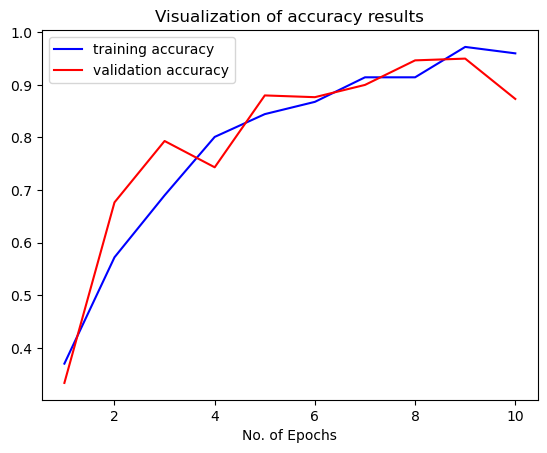

In [22]:
epochs = [i for i in range(1,11)]
plt.plot(epochs, training_history.history['accuracy'], color ='blue',label='training accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color ='red',label='validation accuracy')
plt.xlabel('No. of Epochs')
plt.title("Visualization of accuracy results")
plt.legend()
plt.show()